<a href="https://colab.research.google.com/github/nhjung-phd/TimeSeriesAnalysis/blob/main/notebooks/40_Regression_Evaluation_Metrics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 회귀 평가 지표 실습: TSLA 예측으로 이해하는 오차 기반 지표와 설명력 지표
**Notebook:** `TSLA_Regression_Evaluation_Metrics.ipynb`  
**실행 환경:** Google Colab 권장

---

## 실습 목표
이 실습에서는 **테슬라(TSLA) 주가 데이터**를 이용해 간단한 회귀 예측 모델을 만들고,  
그 예측 결과를 다양한 평가 지표로 측정하는 방법을 학습합니다.

### 이번 실습에서 다루는 평가 지표

#### 📌 오차 기반 지표 (Error-based Metrics)
- 평균 제곱 오차 (**MSE**, Mean Squared Error)
- 평균 절대 오차 (**MAE**, Mean Absolute Error)
- 평균 절대 백분율 오차 (**MAPE**, Mean Absolute Percentage Error)
- 평균 제곱근 오차 (**RMSE**, Root Mean Squared Error)
- 대칭 평균 절대 백분율 오차 (**sMAPE**, Symmetric MAPE)

#### 📌 설명력 기반 지표 (Goodness-of-Fit Metrics)
- 결정계수 (**R²**, Coefficient of Determination)
- 조정 결정계수 (**Adjusted R²**)

---

## 실습 흐름
1. TSLA 데이터 다운로드
2. 예측용 입력 변수(lag features) 생성
3. 간단한 회귀모형 학습
4. 테스트 구간 예측
5. 오차 기반 지표 계산
6. 설명력 기반 지표 계산
7. 실제값 vs 예측값 시각화
8. 각 지표의 해석과 장단점 정리

---

## 핵심 메시지
좋은 회귀모형은 단순히 예측값이 실제값과 가까운 것만이 아니라,
**어떤 관점에서 얼마나 잘 맞는지**를 여러 지표로 함께 판단해야 합니다.

- MSE / RMSE: 큰 오차에 민감
- MAE: 직관적인 평균 오차
- MAPE / sMAPE: 퍼센트 기준의 상대 오차
- R² / Adjusted R²: 모델이 데이터 변동을 얼마나 설명하는지


In [1]:
# ============================================
# 1. 필수 라이브러리 설치 및 불러오기
# ============================================

try:
    import yfinance as yf
except ImportError:
    !pip -q install yfinance
    import yfinance as yf

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.unicode_minus"] = False

print("Libraries loaded successfully.")


Libraries loaded successfully.


## 1. TSLA 데이터 다운로드

이번 실습에서는 Yahoo Finance에서 **TSLA 일별 종가 데이터**를 가져옵니다.

### 왜 TSLA를 사용하는가?
- 데이터 접근이 쉽습니다.
- 가격 움직임이 비교적 크고 직관적입니다.
- 회귀 예측 결과와 오차 지표 차이를 설명하기 좋습니다.


In [2]:
# ============================================
# 2. TSLA 데이터 다운로드
# ============================================

ticker = "TSLA"
start_date = "2019-01-01"
end_date = "2025-01-01"

df = yf.download(ticker, start=start_date, end=end_date, auto_adjust=False, progress=False)

print("Downloaded shape:", df.shape)
display(df.head())


Downloaded shape: (1510, 6)


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA,TSLA
Date,,,,,,
2019-01-02,20.674667,20.674667,21.008667,19.920000,20.406668,174879000
2019-01-03,20.024000,20.024000,20.626667,19.825333,20.466667,104478000
2019-01-04,21.179333,21.179333,21.200001,20.181999,20.400000,110911500
2019-01-07,22.330667,22.330667,22.449333,21.183332,21.448000,113268000
2019-01-08,22.356667,22.356667,22.934000,21.801332,22.797333,105127500


## 2. MultiIndex-safe 종가 추출

`yfinance`는 환경에 따라 컬럼 구조가 다를 수 있으므로,  
항상 안전하게 종가를 추출하는 방식을 사용합니다.


In [3]:
# ============================================
# 3. MultiIndex-safe 종가 추출
# ============================================

def get_close_series(dataframe, ticker_symbol):
    if isinstance(dataframe.columns, pd.MultiIndex):
        return dataframe[("Close", ticker_symbol)].copy()
    return dataframe["Close"].copy()

close_price = get_close_series(df, ticker)
close_price.name = "Close"

display(close_price.head())


,Close
Date,
2019-01-02,20.674667
2019-01-03,20.024000
2019-01-04,21.179333
2019-01-07,22.330667
2019-01-08,22.356667


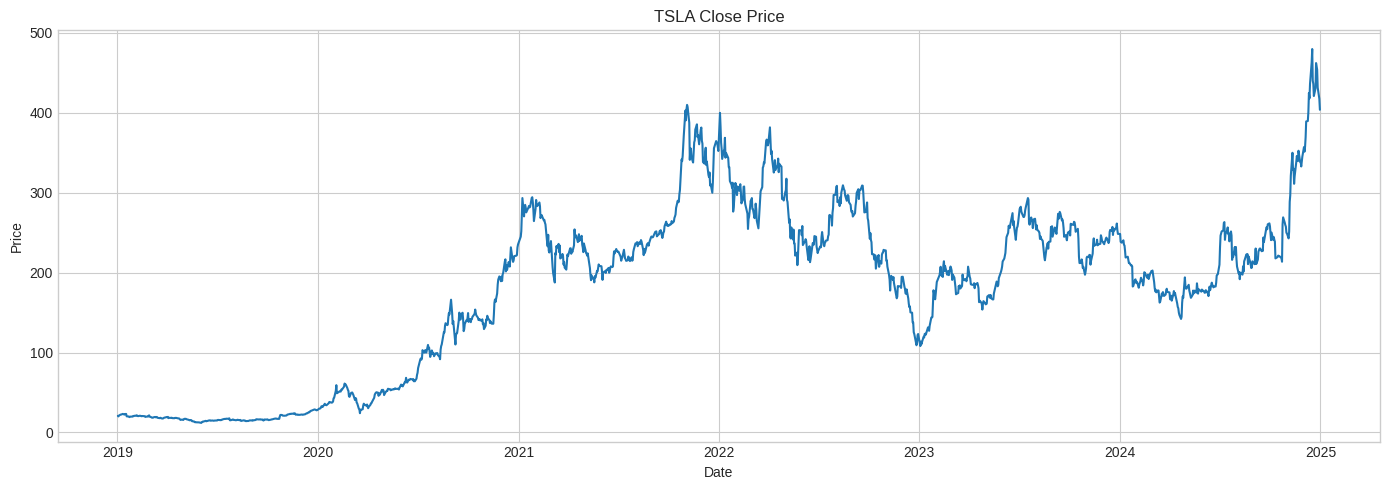

In [4]:
# ============================================
# 4. 종가 시각화
# ============================================

plt.figure(figsize=(14, 5))
plt.plot(close_price.index, close_price, linewidth=1.5)
plt.title("TSLA Close Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.tight_layout()
plt.show()


## 3. 예측 문제 정의

이번 실습에서는 **다음 날 종가(next-day close)** 를 회귀 문제로 예측합니다.

즉,
- 입력: 최근 며칠간의 종가
- 목표: 내일의 종가

### 왜 수익률이 아니라 종가를 예측하는가?
이번 실습의 목표는 **회귀 평가 지표 자체를 학습하는 것**입니다.  
R²와 Adjusted R²를 직관적으로 설명하기 위해 가격 수준 예측을 사용합니다.

> 주의  
> 실제 금융예측 연구에서는 가격 수준 대신 수익률이나 로그수익률을 쓰는 경우가 많습니다.  
> 하지만 여기서는 지표 해석 교육이 목적이므로 종가를 그대로 사용합니다.


In [5]:
# ============================================
# 5. 예측용 데이터프레임 생성
# ============================================

data = pd.DataFrame(index=close_price.index)
data["Close"] = close_price

display(data.head())


,Close
Date,
2019-01-02,20.674667
2019-01-03,20.024000
2019-01-04,21.179333
2019-01-07,22.330667
2019-01-08,22.356667


## 4. Lag feature 만들기

머신러닝 회귀모형은 기본적으로 시계열 구조를 자동으로 이해하지 못합니다.  
그래서 과거 값들을 옆으로 펼쳐 **지도학습용 입력 변수**로 만들어야 합니다.

이번 실습에서는 최근 5일 종가를 입력으로 사용합니다.

- `lag_1`: 하루 전 종가
- `lag_2`: 이틀 전 종가
- ...
- `lag_5`: 5일 전 종가

목표 변수는 다음 날 종가입니다.


In [6]:
# ============================================
# 6. Lag feature 생성
# ============================================

n_lags = 5

for lag in range(1, n_lags + 1):
    data[f"lag_{lag}"] = data["Close"].shift(lag)

# 다음 날 종가를 target으로 사용
data["Target_Next_Close"] = data["Close"].shift(-1)

data = data.dropna().copy()

display(data.head())
print("Prepared dataset shape:", data.shape)


,Close,lag_1,lag_2,lag_3,lag_4,lag_5,Target_Next_Close
Date,,,,,,,
2019-01-09,22.568666,22.356667,22.330667,21.179333,20.024000,20.674667,22.997999
2019-01-10,22.997999,22.568666,22.356667,22.330667,21.179333,20.024000,23.150667
2019-01-11,23.150667,22.997999,22.568666,22.356667,22.330667,21.179333,22.293333
2019-01-14,22.293333,23.150667,22.997999,22.568666,22.356667,22.330667,22.962000
2019-01-15,22.962000,22.293333,23.150667,22.997999,22.568666,22.356667,23.070000


Prepared dataset shape: (1504, 7)


## 5. Train / Test 분할

시계열 회귀도 반드시 시간 순서를 유지해야 합니다.

이번 실습에서는:
- 앞의 80%: 학습(train)
- 뒤의 20%: 테스트(test)

로 나눕니다.


In [7]:
# ============================================
# 7. Train / Test split
# ============================================

feature_cols = [f"lag_{i}" for i in range(1, n_lags + 1)]
target_col = "Target_Next_Close"

split_idx = int(len(data) * 0.8)

train = data.iloc[:split_idx].copy()
test = data.iloc[split_idx:].copy()

X_train = train[feature_cols]
y_train = train[target_col]

X_test = test[feature_cols]
y_test = test[target_col]

print("Train size:", len(train))
print("Test size :", len(test))


Train size: 1203
Test size : 301


## 6. 회귀모형 학습

이번 실습에서는 **Linear Regression**을 사용합니다.

### 왜 선형회귀인가?
- 지표 해석이 명확합니다.
- 계산이 빠릅니다.
- R²와 Adjusted R² 설명에 적합합니다.


In [8]:
# ============================================
# 8. 선형회귀 학습
# ============================================

model = LinearRegression()
model.fit(X_train, y_train)

test["Predicted_Close"] = model.predict(X_test)

display(test[["Close", "Target_Next_Close", "Predicted_Close"]].head())


,Close,Target_Next_Close,Predicted_Close
Date,,,
2023-10-19,220.110001,211.990005,242.678555
2023-10-20,211.990005,212.080002,220.558031
2023-10-23,212.080002,216.520004,211.064054
2023-10-24,216.520004,212.419998,209.971779
2023-10-25,212.419998,205.759995,214.976506


## 7. 실제값 vs 예측값 시각화

이 단계에서는 모델이 대략적인 추세를 얼마나 잘 따라가는지 직관적으로 확인합니다.

### 해석 포인트
- 예측선이 실제값과 비슷한 방향으로 움직이는가?
- 급등락 구간에서 오차가 커지는가?
- 전체 수준(level)은 잘 맞는데 세부 변동은 놓치는가?


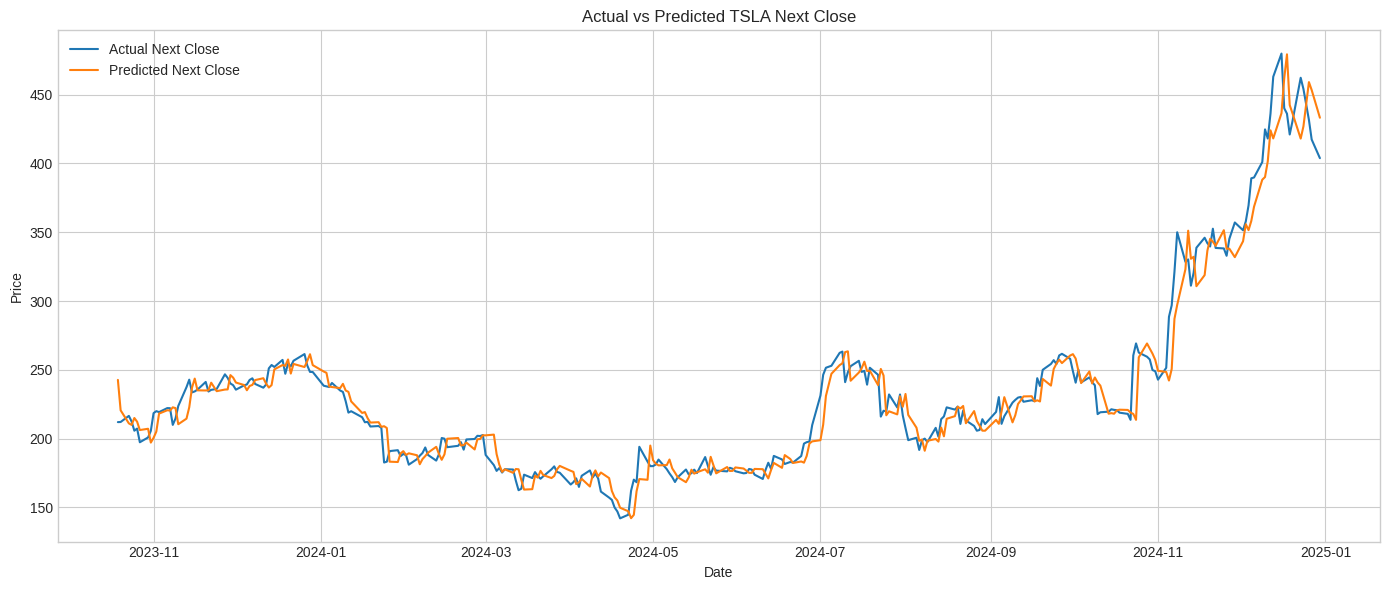

In [9]:
# ============================================
# 9. 실제값 vs 예측값 시각화
# ============================================

plt.figure(figsize=(14, 6))
plt.plot(test.index, test["Target_Next_Close"], label="Actual Next Close", linewidth=1.5)
plt.plot(test.index, test["Predicted_Close"], label="Predicted Next Close", linewidth=1.5)

plt.title("Actual vs Predicted TSLA Next Close")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.tight_layout()
plt.show()


## 8. 오차 기반 지표 함수 정의

이제 본격적으로 회귀 오차 지표를 계산합니다.

### 각 지표의 의미
- **MSE**: 오차 제곱의 평균
- **MAE**: 오차 절대값의 평균
- **MAPE**: 실제값 대비 평균 퍼센트 오차
- **RMSE**: MSE에 루트를 취한 값
- **sMAPE**: MAPE의 비대칭성 문제를 완화한 대칭적 백분율 오차


In [10]:
# ============================================
# 10. 오차 기반 지표 함수
# ============================================

def mape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def smape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    # denominator가 0이면 계산이 불안정할 수 있으므로 작은 값을 더해줌
    return np.mean(np.abs(y_true - y_pred) / (denominator + 1e-8)) * 100


## 9. Adjusted R² 계산

조정 결정계수(Adjusted R²)는  
단순히 변수를 많이 넣는다고 R²가 무조건 올라가는 문제를 보정하기 위해 사용합니다.

### 공식
\[
Adjusted\ R^2 = 1 - (1-R^2) \times \frac{n-1}{n-p-1}
\]

- \(n\): 표본 수
- \(p\): 설명변수 수

즉,  
변수가 늘어날수록 설명력이 정말 개선되었는지를 더 엄격하게 보는 지표입니다.


In [11]:
# ============================================
# 11. Adjusted R² 함수
# ============================================

def adjusted_r2(r2, n, p):
    if n - p - 1 <= 0:
        return np.nan
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)


## 10. 모든 평가 지표 계산

이제 테스트 구간 예측값을 기준으로  
오차 기반 지표와 설명력 기반 지표를 한 번에 계산합니다.


In [12]:
# ============================================
# 12. 평가 지표 계산
# ============================================

y_true = test["Target_Next_Close"]
y_pred = test["Predicted_Close"]

mse_value = mean_squared_error(y_true, y_pred)
mae_value = mean_absolute_error(y_true, y_pred)
rmse_value = np.sqrt(mse_value)
mape_value = mape(y_true, y_pred)
smape_value = smape(y_true, y_pred)

r2_value = r2_score(y_true, y_pred)
adj_r2_value = adjusted_r2(r2_value, n=len(y_true), p=len(feature_cols))

metrics_df = pd.DataFrame({
    "Metric": [
        "MSE",
        "MAE",
        "MAPE (%)",
        "RMSE",
        "sMAPE (%)",
        "R²",
        "Adjusted R²"
    ],
    "Value": [
        mse_value,
        mae_value,
        mape_value,
        rmse_value,
        smape_value,
        r2_value,
        adj_r2_value
    ]
})

display(metrics_df)


,Metric,Value
0,MSE,192.494745
1,MAE,9.542442
2,MAPE (%),3.944220
3,RMSE,13.874248
4,sMAPE (%),3.971151
5,R²,0.954689
6,Adjusted R²,0.953921


## 11. 결과를 보기 좋은 표로 정리

일부 지표는 소수점 자릿수를 정리하면 해석이 더 쉽습니다.


In [13]:
# ============================================
# 13. 보기 좋은 형식으로 정리
# ============================================

formatted = metrics_df.copy()

formatted["Value"] = formatted.apply(
    lambda row: f"{row['Value']:.4f}" if "R²" in row["Metric"] or row["Metric"] in ["MSE", "MAE", "RMSE"]
    else f"{row['Value']:.2f}",
    axis=1
)

display(formatted)


,Metric,Value
0,MSE,192.4947
1,MAE,9.5424
2,MAPE (%),3.94
3,RMSE,13.8742
4,sMAPE (%),3.97
5,R²,0.9547
6,Adjusted R²,0.9539


## 12. 각 지표를 어떻게 해석할까?

### MSE (Mean Squared Error)
- 오차를 제곱해서 평균낸 값
- 큰 오차에 매우 민감
- 단위가 원래 값의 제곱이라 직관성은 낮음

### MAE (Mean Absolute Error)
- 평균적으로 얼마나 틀렸는지 직관적으로 보여줌
- 이상치에 MSE보다 덜 민감

### RMSE (Root Mean Squared Error)
- MSE에 루트를 취해 원래 단위로 되돌린 지표
- 큰 오차를 더 강하게 벌점 주고 싶을 때 자주 사용

### MAPE
- 실제값 대비 몇 % 틀렸는지 보여줌
- 직관적이지만 실제값이 0 또는 0에 가까우면 불안정

### sMAPE
- MAPE보다 더 대칭적인 퍼센트 오차
- 실제값과 예측값이 모두 작은 구간에서도 상대적으로 안정적

### R²
- 모델이 데이터 변동성을 얼마나 설명하는지 보여줌
- 1에 가까울수록 설명력이 높음

### Adjusted R²
- 변수가 많아졌을 때의 과도한 설명력 상승을 보정
- 여러 모델 비교 시 더 공정한 지표


## 13. 지표별 장단점 요약표


In [14]:
# ============================================
# 14. 지표 요약표
# ============================================

summary_table = pd.DataFrame({
    "Metric": ["MSE", "MAE", "MAPE", "RMSE", "sMAPE", "R²", "Adjusted R²"],
    "Strength": [
        "큰 오차를 강하게 반영",
        "직관적인 평균 오차",
        "퍼센트 기준 해석 용이",
        "원래 단위로 해석 가능",
        "대칭적 상대 오차",
        "설명력 직관적 제시",
        "변수 수 보정 가능"
    ],
    "Weakness": [
        "단위가 제곱이라 직관성 낮음",
        "큰 오차에 덜 민감",
        "실제값이 0에 가까우면 불안정",
        "이상치 영향 큼",
        "해석이 익숙하지 않을 수 있음",
        "변수 많으면 과대평가 가능",
        "작은 표본에서는 민감할 수 있음"
    ]
})

display(summary_table)


,Metric,Strength,Weakness
0,MSE,큰 오차를 강하게 반영,단위가 제곱이라 직관성 낮음
1,MAE,직관적인 평균 오차,큰 오차에 덜 민감
2,MAPE,퍼센트 기준 해석 용이,실제값이 0에 가까우면 불안정
3,RMSE,원래 단위로 해석 가능,이상치 영향 큼
4,sMAPE,대칭적 상대 오차,해석이 익숙하지 않을 수 있음
5,R²,설명력 직관적 제시,변수 많으면 과대평가 가능
6,Adjusted R²,변수 수 보정 가능,작은 표본에서는 민감할 수 있음


## 14. 같은 데이터를 다른 기준으로 보면 해석이 달라진다

중요한 점은 **어떤 지표를 쓰느냐에 따라 모델 평가가 달라질 수 있다**는 것입니다.

예를 들어,
- 큰 오차를 특히 싫다면 → **MSE / RMSE**
- 평균적인 오차 크기가 중요하다면 → **MAE**
- 비율 오차가 중요하다면 → **MAPE / sMAPE**
- 설명력이 중요하다면 → **R² / Adjusted R²**

즉, 단 하나의 지표만 보고 “좋은 모델”이라고 결론 내리기보다,  
문제의 목적에 맞는 지표 조합을 선택해야 합니다.


## 15. 추가 실험 아이디어

이번 실습은 가장 단순한 형태의 회귀 평가 예제입니다.  
다음과 같이 확장해 볼 수 있습니다.

- 선형회귀 대신 Random Forest, XGBoost, MLP 사용
- 입력 변수 수(lag 개수) 변화에 따른 R² / Adjusted R² 비교
- Close 대신 Return을 예측 대상으로 변경
- TSLA 외 AAPL, NVDA, MSFT와 비교
- Walk-forward validation으로 평가 구조 확장


## 16. 최종 정리

이번 실습에서 우리는 TSLA 데이터로 회귀 예측을 수행하고,  
다음 두 그룹의 평가 지표를 계산했습니다.

### 📌 오차 기반 지표
- MSE
- MAE
- MAPE
- RMSE
- sMAPE

### 📌 설명력 기반 지표
- R²
- Adjusted R²

### 핵심 결론
- 오차 기반 지표는 **예측값과 실제값의 거리**를 본다.
- 설명력 기반 지표는 **모델이 데이터 변동을 얼마나 설명하는지**를 본다.
- 좋은 모델 평가는 하나의 숫자가 아니라 **여러 지표를 함께 읽는 과정**이다.


## 17. 연습문제 (Exercises)

1. `lag_5` 대신 `lag_10`까지 사용하면 R²와 Adjusted R²는 어떻게 변하는가?
2. TSLA 대신 AAPL 데이터를 사용했을 때 MAPE와 RMSE를 비교하시오.
3. Linear Regression 대신 `RandomForestRegressor`를 사용하여 같은 지표를 계산하시오.
4. 실제값이 매우 작은 구간에서는 MAPE와 sMAPE가 어떻게 다르게 반응하는지 확인하시오.
5. 어떤 상황에서 MAE보다 RMSE를 선호해야 하는지 자신의 말로 설명하시오.
